**1. Опис проекту**

Набір даних містить оголошення про продаж квартир у 15 найбільших містах Польщі. Дані були отримані з локальних сайтів нерухомості та охоплюють період з серпня 2023 року по червень 2024 року.


Попередньо дані пройшли очищення за допомогою SQL. Був проведений аналіз пропусків, видалення дублікатів, виправлення типів даних, видалення пошкоджених записів

**2. Завантаження та первинне дослідження даних**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from google.colab import drive

In [2]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/data/apartments_final.csv', sep=';')
df.head()

Mounted at /content/drive


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,price_per_m2
0,79265665d026fc307d5ac14a51b1b39f,katowice,tenement,31.73,1,NaN,NaN,NaN,condominium,brick,False,False,False,True,True,169900,5354.55
1,9089ab1cd5d745d42a72e28fc1e60056,warszawa,blockOfFlats,60.00,3,NaN,NaN,NaN,condominium,unknown,False,False,NaN,False,False,760000,12666.67
2,b3e0e0d3a6c8e0908262a5a6c7ab57bd,wroclaw,tenement,59.60,2,NaN,NaN,NaN,condominium,brick,False,True,False,False,True,620000,10402.68
3,0b538b2f8a61c0928424587e32c9aeb9,gdansk,unknown,68.00,3,NaN,NaN,NaN,condominium,unknown,False,False,True,False,False,799000,11750.00
4,b1e2c390e328186dd3163d53df67496b,gdynia,unknown,120.00,5,NaN,NaN,NaN,condominium,unknown,False,False,NaN,False,False,1120000,9333.33




Для отримання базової інформації про датасет

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18676 entries, 0 to 18675
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                18676 non-null  object 
 1   city              18676 non-null  object 
 2   type              18676 non-null  object 
 3   squareMeters      18676 non-null  float64
 4   rooms             18676 non-null  int64  
 5   floor             15284 non-null  float64
 6   floorCount        18419 non-null  float64
 7   buildYear         15467 non-null  float64
 8   ownership         18676 non-null  object 
 9   buildingMaterial  18676 non-null  object 
 10  hasParkingSpace   18676 non-null  bool   
 11  hasBalcony        18676 non-null  bool   
 12  hasElevator       17771 non-null  object 
 13  hasSecurity       18676 non-null  bool   
 14  hasStorageRoom    18676 non-null  bool   
 15  price             18676 non-null  int64  
 16  price_per_m2      18676 non-null  float6

,squareMeters,rooms,floor,floorCount,buildYear,price,price_per_m2
count,18676.000000,18676.000000,15284.000000,18419.000000,15467.000000,1.867600e+04,18676.000000
mean,58.881584,2.693832,3.330280,5.269396,1984.588220,6.960977e+05,11979.434284
std,20.917061,0.894347,2.537615,3.324271,33.772704,3.446526e+05,4339.956072
min,25.000000,1.000000,1.000000,1.000000,1850.000000,1.500000e+05,3011.630000
25%,44.930000,2.000000,2.000000,3.000000,1967.000000,4.598858e+05,8784.770000
50%,54.940000,3.000000,3.000000,4.000000,1990.000000,6.250000e+05,11348.760000
75%,68.570000,3.000000,4.000000,6.000000,2014.000000,8.363228e+05,14417.152500
max,150.000000,6.000000,29.000000,29.000000,2023.000000,2.500000e+06,29995.100000


Датасет містить 18 676 оголошень про продаж квартир у Польщі та 17 змінних, що описують характеристики нерухомості, зокрема площу, кількість кімнат, поверх, рік побудови, наявність паркінгу та ціну.

**3. Аналіз якості даних**

In [4]:
# перевірка пропусків
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'count': missing,
    'percent': round(missing / len(df) * 100, 2)
})

missing_df.sort_values('percent', ascending=False)

,count,percent
floor,3392,18.16
buildYear,3209,17.18
hasElevator,905,4.85
floorCount,257,1.38
id,0,0.00
rooms,0,0.00
squareMeters,0,0.00
type,0,0.00
city,0,0.00
ownership,0,0.00


Аналіз пропущених значень показав, що найбільша частка пропусків спостерігається у змінних floor (18.16%) та buildYear (17.18%). Інші змінні мають незначний рівень пропусків (менше 5%). Враховуючи важливість цих ознак для подальшого аналізу, було прийнято рішення зберегти їх у датасеті та обробляти пропуски на етапі аналізу або візуалізації.

**4. Описова статистика**

In [5]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
squareMeters,18676.0,58.881584,20.917061,25.00,44.93,54.94,68.5700,150.0
rooms,18676.0,2.693832,0.894347,1.00,2.00,3.00,3.0000,6.0
floor,15284.0,3.330280,2.537615,1.00,2.00,3.00,4.0000,29.0
floorCount,18419.0,5.269396,3.324271,1.00,3.00,4.00,6.0000,29.0
buildYear,15467.0,1984.588220,33.772704,1850.00,1967.00,1990.00,2014.0000,2023.0
price,18676.0,696097.699561,344652.559536,150000.00,459885.75,625000.00,836322.7500,2500000.0
price_per_m2,18676.0,11979.434284,4339.956072,3011.63,8784.77,11348.76,14417.1525,29995.1


У вибірці переважають квартири середнього розміру, а дуже великі об'єкти представлені відносно рідко. Також найбільший попит мають квартири із 3 кімнатами. Більшість квартир знаходиться в малоповерхових або середньоповерхових будинках. Значна частина житлового фонду представлена будинками XX століття. Середня ціна перевищує медіанну, що свідчить про наявність дорогих об'єктів, котрі зміщують середнє значення вгору.На ринку спостерігається значна варіативність вартості квадратного метра, це може пояснюватись відмінностями між містами, типами житла та роком побудови.

**5. Перевірка статистичної гіпотези**


Перевірку гіпотези буду проводити завдяки t-test.
Вплив паркінгу на ціну квартири

Нульова гіпотеза (H₀):
Середня ціна квартир з паркінгом і без паркінгу однакова.
Альтернативна гіпотеза (H₁):
Середня ціна квартир з паркінгом відрізняється від середньої ціни квартир без паркінгу.

In [6]:
parking = df[df['hasParkingSpace'] == True]['price']
no_parking = df[df['hasParkingSpace'] == False]['price']

t_stat, p_value = ttest_ind(
    parking,
    no_parking,
    equal_var=False  # Welch's t-test
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

T-statistic: 19.2017
P-value: 0.0000000000


Оскільки p-value значно менше рівня значущості α = 0.05, нульову гіпотезу було відхилено. Отримані результати свідчать про наявність статистично значущої різниці між середньою вартістю квартир з паркінгом та без паркінгу.

Середня ціна квартири із паркінгом становить -  781 934 zł
Середня ціна квартири без паркінгу складає  - 666 004 zł.
Різниця:

781 934 − 666 004 = 115 930 zł


Квартири з паркінгом коштують у середньому на 115 930 zł дорожче, ніж квартири без паркінгу. Статистичний тест підтвердив, що ця різниця є статистично значущою і навряд чи пояснюється випадковими коливаннями даних.

**6. Підготовка даних для моделювання**

Побудова моделі, яка прогнозує вартість квартири на основі її характеристик.

In [7]:
# створюємо робочу таблицю
ml_df = df[
    ['squareMeters',
     'rooms',
     'buildYear',
     'hasParkingSpace',
     'price']
].copy()

In [8]:
# перевіряємо пропуски
ml_df.isnull().sum()

,0
squareMeters,0
rooms,0
buildYear,3209
hasParkingSpace,0
price,0


In [9]:
# заповнюю пропуски buildYear медіанним значенням
ml_df['buildYear'] = ml_df['buildYear'].fillna(
    ml_df['buildYear'].median()
)


In [10]:
# перетворюю bool у 0/1
ml_df['hasParkingSpace'] = ml_df['hasParkingSpace'].astype(int)

In [11]:
# перевіряю результат
ml_df.isnull().sum()

,0
squareMeters,0
rooms,0
buildYear,0
hasParkingSpace,0
price,0


In [12]:
# запускаю модель
X = ml_df.drop('price', axis=1)
y = ml_df['price']

**7. Побудова та оцінка моделі**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 194820.13
RMSE: 265229.09
R²: 0.4266


Побудована модель лінійної регресії пояснює близько 43% варіації вартості квартир (R² = 0.43). Отриманий результат свідчить, що площа, кількість кімнат, рік побудови та наявність паркінгу мають помітний вплив на ціну житла. Водночас значна частина варіації залишається непоясненою, це може бути пов'язано з відсутністю в моделі таких важливих характеристик, як місто, район розташування та інші особливості об'єкта нерухомості.

**8. Візуальний аналіз ринку нерухомості**

8.1 Розподіл цін квартир

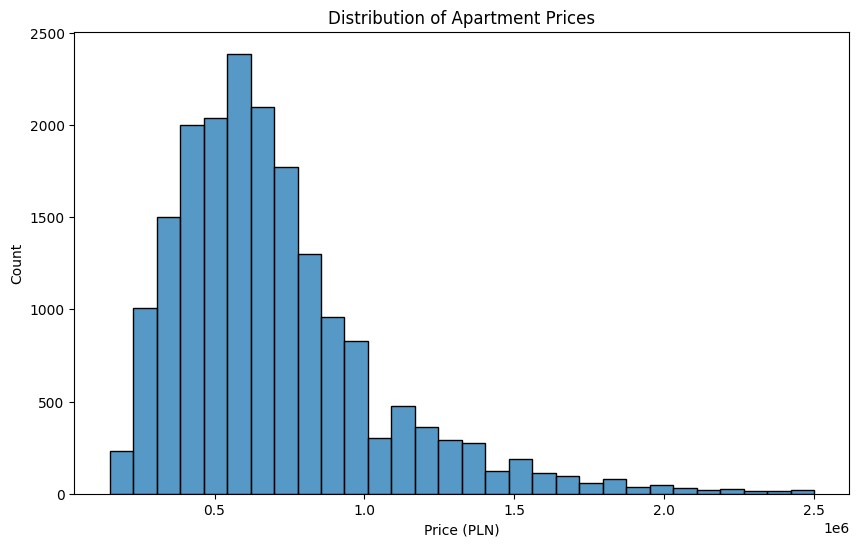

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=30)

plt.title('Distribution of Apartment Prices')
plt.xlabel('Price (PLN)')
plt.ylabel('Count')

plt.show()

Розподіл цін квартир має правосторонній скіс (позитивну асиметрію). Більшість квартир зосереджена в середньому ціновому сегменті, тоді як невелика кількість дорогих об'єктів формує довгий правий хвіст розподілу. Це свідчить про наявність преміального сегмента на ринку нерухомості.

8.2 Ціна залежно від кількості кімнат

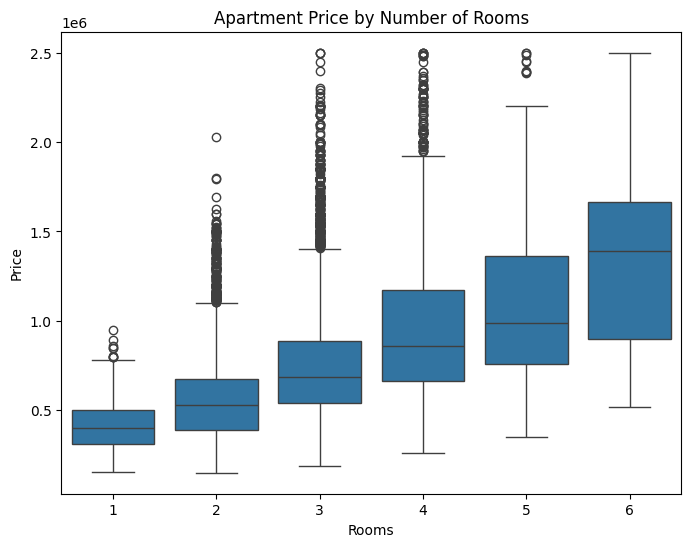

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x='rooms', y='price', data=df)

plt.title('Apartment Price by Number of Rooms')
plt.xlabel('Rooms')
plt.ylabel('Price')

plt.show()

 Зі збільшенням кількості кімнат медіанна ціна квартири стабільно зростає. Також спостерігається збільшення варіативності цін для великих квартир, що свідчить про більший вплив додаткових характеристик нерухомості на їхню вартість. На графіку присутні численні викиди, які представляють квартири преміум-сегменту з надзвичайно високими цінами.

8.3 Зв'язок площі та ціни

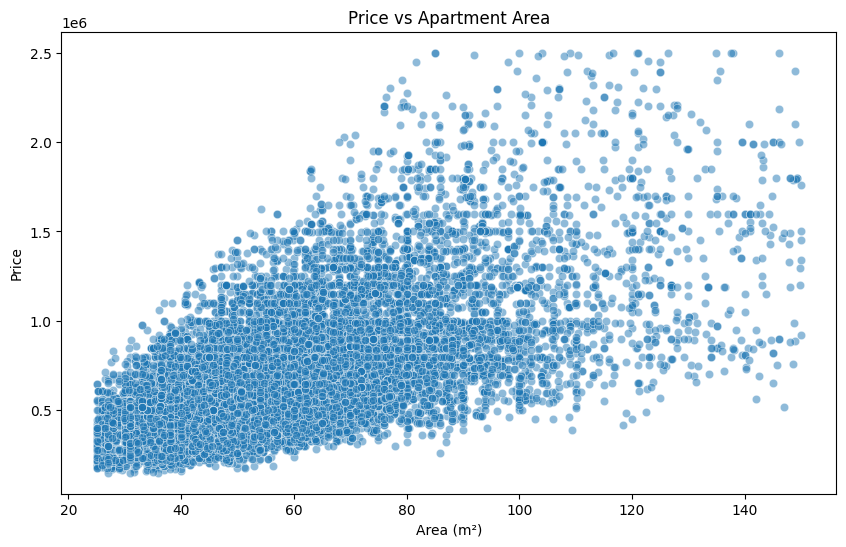

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='squareMeters',
    y='price',
    alpha=0.5
)

plt.title('Price vs Apartment Area')
plt.xlabel('Area (m²)')
plt.ylabel('Price')

plt.show()

Діаграма розсіювання показала позитивний зв'язок між площею квартири та її вартістю: зі збільшенням площі ціна житла в середньому зростає. Водночас для квартир однакового розміру спостерігається значний розкид цін, що свідчить про вплив додаткових факторів, таких як місто розташування, рік побудови та характеристики об'єкта. Також було виявлено преміальні квартири з ціною понад 2 млн zł, які виступають викидами у вибірці.

8.4 Ціна за м² по містах

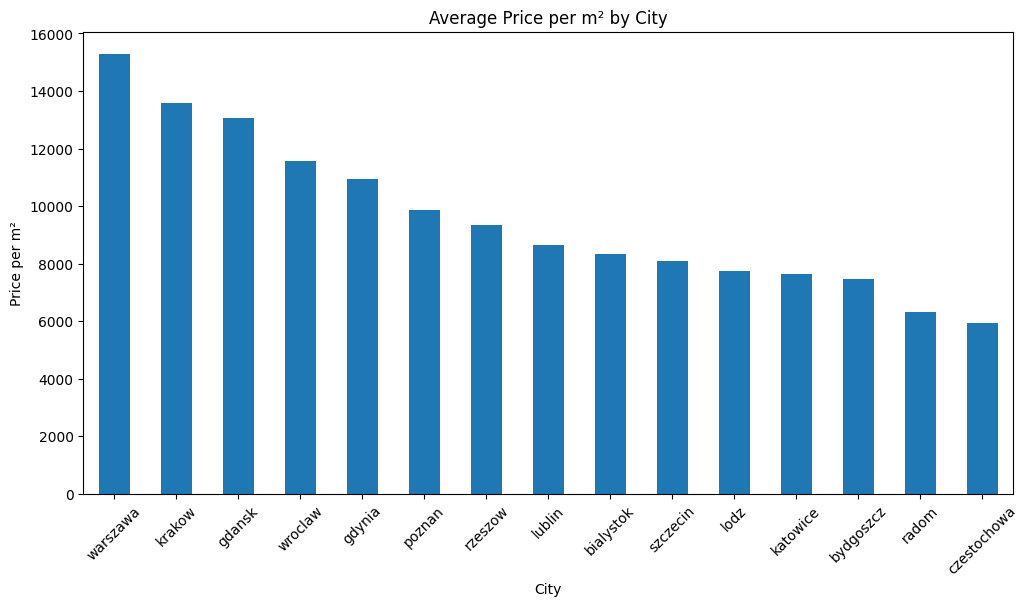

In [18]:
city_price = (
    df.groupby('city')['price_per_m2']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
city_price.plot(kind='bar')

plt.title('Average Price per m² by City')
plt.xlabel('City')
plt.ylabel('Price per m²')

plt.xticks(rotation=45)
plt.show()

Аналіз вартості квадратного метра показав, що Варшава є найдорожчим ринком житла серед досліджуваних міст. Середня ціна за м² у столиці становить 15 303 zł, що більш ніж у 2,5 раза перевищує аналогічний показник у Ченстохові. Найдоступнішими містами за вартістю житла виявилися Ченстохова та Радом.

8.5 Новобудови та старий фонд

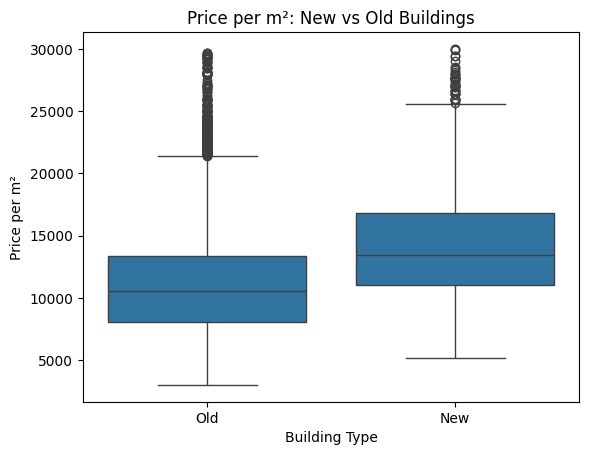

In [19]:
df['building_age'] = np.where(
    df['buildYear'] >= 2010,
    'New',
    'Old'
)

sns.boxplot(
    data=df,
    x='building_age',
    y='price_per_m2'
)

plt.title('Price per m²: New vs Old Buildings')
plt.xlabel('Building Type')
plt.ylabel('Price per m²')

plt.show()

Boxplot демонструє, що новобудови мають вищу медіанну ціну порівняно зі старим житловим фондом. Крім того, для нових будинків спостерігається більший розкид цін та більше дорогих об'єктів серед викидів. Це підтверджує попередній аналіз, згідно з яким середня вартість квартири та ціна за квадратний метр у новобудовах є вищими.

In [20]:
df.to_csv('apartments_final_clean.csv', index=False)

In [21]:
from google.colab import files

files.download('apartments_final_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>